In [1]:
#solve the low thrust optimization problem as an nlp 

#we want to be able to match this solution with the polynomial optimization methods
using Pkg
Pkg.activate(".")

  Activating project at `~/Research/polynomial_opt`


In [2]:
#dircol: polynomial splines to represent trajectoories and enforce dynamics as constraints on spline derivatives
#specifically use cubic splines for states and piecewise linear interpolation for controls 

In [3]:
#here, we are doing zero order hold on the controls and hermite simpson integration 

In [4]:
#write down the problem in such a way that it can be written as a qcqp 
#but just write down f(x) and c(x), not in the form x'Ax yet.

In [5]:
using Test 
using LinearAlgebra
using SparseArrays
using Plots
using ForwardDiff
import lazy_nlp_qd 

In [6]:
#sizes of all the states 
nq = 3
nv = 3
na = 3
nr = 1
nu = 3
ns = 1
nw = 1
#states a half knot point. (not added as state variables with hermite simpson integration )
nq_half = 3
nv_half = 3
na_half = 3
nr_half = 1
ns_half = 1
nw_half = 1


1

In [7]:
#gravitational parameter for the Earth 
μ = 3.986004418e5 #km3/s2

398600.4418

In [8]:
#iss initial conditions
r0 = [6791.0; 0; 0] #km
v0 = [0; cosd(51.5)*7.66; sind(51.5)*7.66] #km/s
x_initial_0 = [r0; v0]

6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [9]:
#finding the period
r_initial = norm(r0)

#for 1 rev
iss_period = 2*pi*sqrt(r_initial^3/μ)

5569.440597283014

In [10]:
#working for 1 rev ...
#revs = 1

#around 8 min solve time... (working)
#revs = 10

#revs for polynomial opt example (working) 4 second solve time 
revs = 20

#period 
#total period 
period = revs*iss_period 

111388.81194566027

In [11]:
#working with 10 rev horizon 
#knot_pts = 30

#course discretization that we try out in the polynomial opt example
#working with 5 rev horizon
knot_pts = 10

#knot_pts = 41

#number of knot points  
N=knot_pts*revs

200

In [12]:
#define a timestep
#in seconds 
h = period/(N-1) 

559.7427735962827

In [13]:
#incorporate control here

function two_body_dynamics(x, u)

    q = x[1:3]
    v = x[4:6]

    a = zeros(eltype(x), size(x))

    r = norm(q)
    
    a[1:3] = v

    #treat control as an additive acceleration 
    
    a[4:6] = ((-μ/r^3)*q) + u

    return a

end

two_body_dynamics (generic function with 1 method)

In [14]:
#hermite simpson integration

#pass in x1 and an initial guess for x2. solve root finding problem for x2
#x is state and velocity here 

#used to simulate and get the initial guess trajectory

#passing in zeros for the control trajectory 
function hermite_simpson_residual(xk, xk1, uk, uk1)

    x_k_dot = two_body_dynamics(xk, uk)
    
    x_k1_dot = two_body_dynamics(xk1, uk1)

    x_half = 0.5*(xk+xk1) + (h/8.0)*(x_k_dot - x_k1_dot)

    x_half_dot = two_body_dynamics(x_half, zeros(3))

    residual = xk + (h/6.0)*(x_k_dot + 4*x_half_dot + x_k1_dot) - xk1

    return residual 

end

hermite_simpson_residual (generic function with 1 method)

In [15]:
function newtons_method(xk, xk1)


    all_residuals = zeros(6, max_iters)
    all_xk1 = zeros(6, max_iters)
    all_xk1[:,1] = xk1

    for i=1:max_iters-1

        all_residuals[:,i] = hermite_simpson_residual(xk, all_xk1[:,i], zeros(3), zeros(3))
        
        #println("Residual Iteration", i,  norm(all_residuals[:,i]))

        if norm(all_residuals[:,i]) < 1e-4

            return all_xk1[:,i], all_residuals

        end
        
        jacobian = ForwardDiff.jacobian(dxk1 -> hermite_simpson_residual(xk, dxk1, zeros(3), zeros(3)), all_xk1[:,i])

        Δx = -jacobian\all_residuals[:,i] 

        all_xk1[:,i+1] += all_xk1[:,i] + Δx

    end

    println("did not converge...")

    return all_xk1[:,end], all_residuals

end

newtons_method (generic function with 1 method)

In [16]:
# #semi implicit euler 
# function symplectic_euler(x)

#     #the q and the v are already scaled 
#     q = x[1:3]
#     v = x[4:6]

#     #next timestep
#     xnext = zeros(6)

#     #ak = two_body_dynamics(x)[4:6]
#     ak = (-μ/(norm(q)^3))*q
#     #ak = (-μ_scaled/(norm(q)^3))*q


#     #explicit euler on the velocities
#     #vk1
#     xnext[4:6] = v + h*ak

#     #implicit euler on the positions
#     #qk1
#     xnext[1:3] = q + h*xnext[4:6]

#     return xnext 

# end

In [17]:
#integrate the orbit with symplectic euler to see if it closes

xtraj = zeros(6, N)

xtraj[:,1] = x_initial_0


6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [18]:
#integration is working (test code)
max_iters = 20
#x_k1, residual = newtons_method(xtraj[:,1], xtraj[:,1]) 

20

In [19]:
#simulate the 5 revolutions 

for i=1:N-1
    #solve for k+1 with state at k at the initial state 
    
    xtraj[:,i+1], _ = newtons_method(xtraj[:,i], xtraj[:,i]) 

end

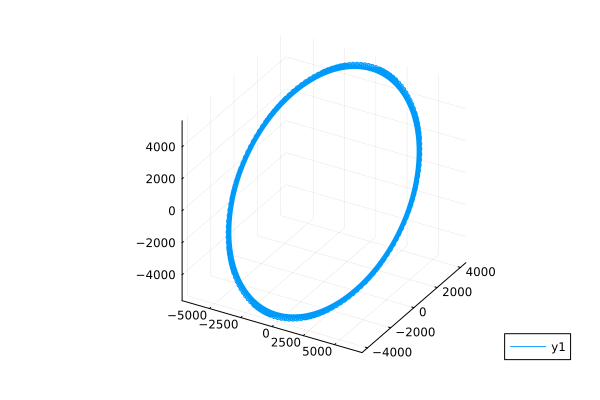

In [20]:
plot(xtraj[1,:], xtraj[2,:], xtraj[3,:])

In [21]:
#find the mid points using xtraj to use as an initial guess

#not part of the state (maybe)

xtraj_half = zeros(6, N-1)

for i=1:N-1

    x_dot_k = two_body_dynamics(xtraj[:,i], zeros(3))

    x_dot_k1 = two_body_dynamics(xtraj[:,i+1], zeros(3))

    xtraj_half[:,i] = 0.5*(xtraj[:,i] + xtraj[:,i+1]) + (h/8.0)*(x_dot_k - x_dot_k1) 

end

In [22]:
# #integrate using symplectic Euler to generate an initial guess
# for i=1:N-1

#     xtraj[:,i+1] = symplectic_euler(xtraj[:,i])

# end


In [23]:
#going to scale position by semi major axis length 
position_scale = r_initial 

#scaled to make the period 1 
#time_scale = iss_period 
#works with 1
#thrust_limit_kN = 0.000432

#this works with 29% sub opt gap  (block structure)
#0.6% opt gap with MD structure 
#this is working...
#thrust_limit_kN = 0.00002

#2 Newtons 
#thrust_limit_kN = 0.002

#2 milliNewton
#thrust_limit_kN = 0.000002

thrust_limit_kN = 20e-9

#currently in the testing code
#this works 
#thrust_limit_kN = 2e-5

#scale to make the minimum control 1
#time_scale = sqrt(position_scale/thrust_limit_kN)

#scaled to make the period 1
time_scale = period 

velocity_scale = position_scale/time_scale

acceleration_scale = position_scale/time_scale^2

μ_scaled = μ/(position_scale^3/time_scale^2)

h_scaled = h/time_scale

u_max_bound = thrust_limit_kN/acceleration_scale 

0.03654091422961469

In [24]:
h_scaled 

0.005025125628140704

In [25]:
time_scale 

111388.81194566027

In [26]:
xtraj_scaled = [xtraj[1:3,:]./position_scale; xtraj[4:6,:]./velocity_scale]

6×200 Matrix{Float64}:
  1.0       0.807069     0.302555  …    0.526018   0.926725    0.969132
  0.0       0.367329     0.592802      -0.528352  -0.232672    0.153024
  0.0       0.461795     0.745254      -0.664229  -0.292508    0.192377
  0.0     -74.2421    -119.885        107.028     47.1573    -30.8201
 78.2143   63.121       23.6193        41.1874    72.5587     75.8391
 98.3289   79.354       29.6936    …   51.7796    91.2187     95.3428

In [27]:
xtraj_half_scaled = [xtraj_half[1:3,:]./position_scale; xtraj_half[4:6,:]./velocity_scale]

6×199 Matrix{Float64}:
   0.950169     0.583482    -0.0085971  …    0.235404   0.763979   0.996909
   0.193145     0.504878     0.621501       -0.603597  -0.400217  -0.0418846
   0.242817     0.634718     0.781334       -0.758825  -0.503142  -0.0526562
 -39.0293    -102.066     -125.73          122.292     81.0649     8.57394
  74.3137      45.6187      -0.766706       18.4016    59.824     78.0306
  93.4252      57.3506      -0.963881   …   23.134     75.2091    98.0979

In [28]:
#solve for a_traj_scaled
a_traj_scaled = zeros(3, N)


for i=1:N

    a_traj_scaled[:,i] = (-μ_scaled/(norm(xtraj_scaled[1:3, i])^3))*xtraj_scaled[1:3, i] 

end

In [29]:
a_traj_scaled 

3×200 Matrix{Float64}:
 -15791.4  -12753.4    -4789.55    5059.33  …  -8343.42  -14666.9   -15312.2
     -0.0   -5804.57   -9384.27   -9344.57      8380.44    3682.39   -2417.75
     -0.0   -7297.35  -11797.6   -11747.7      10535.7     4629.4    -3039.53

In [30]:
#solve for a_traj_half_scaled

a_traj_half_scaled = zeros(3, N-1)

for i=1:N-1

    a_traj_half_scaled[:,i] = (-μ_scaled/(norm(xtraj_half_scaled[1:3, i])^3))*xtraj_half_scaled[1:3, i] 

end

In [31]:
#updated for u and n variables in the ipopt projection problem

#add ns and nw for the  

function create_idx(nq, nv, na, nr, nu, ns, nw, N)

    # This function creates some useful indexing tools for Z 
    # q_i = Z[idx.q[i]]
    # v_i = Z[idx.v[i]]
    # a_i = Z[idx.a[i]]
    # r_i = Z[idx.r[i]]
    # u_i = Z[idx.u[i]]

    #stacked up vector 
    # z = [all_q, all_v, all_a, all_r, all_u]

    #length of the entire stacked up vector 
    nz = (N*nq) + (N*nv) + (N*na) + N*(nr) + ((N-1)*nu) + (N*ns) + (N*nw) + ((N-1)*nq_half) + ((N-1)*nv_half) + ((N-1)*na_half) + ((N-1)*nr_half) + ((N-1)*ns_half) + ((N-1)*nw_half)

    #all the states are stacked up in this order
    # [q v a r u s w q_half v_half a_half r_half s_half w_half]
    q = [(i-1)*(nq) .+ (1:nq) for i=1:N]

    v = [(i-1)*(nv) .+ (nq*N+1:nq*N+nv) for i=1:N]

    a = [(i-1)*(na) .+ (nq*N+ nv*N + 1:nq*N+ nv*N+na) for i=1:N]

    r = [(i-1)*(nr) .+ (nq*N+ nv*N + na*N +nr) for i=1:N]

    u = [(i-1)*(nu) .+ (nq*N+ nv*N + na*N + nr*N+1:nq*N+ nv*N + na*N + nr*N +nu) for i=1:N-1]

    s = [(i-1)*(ns) .+ (nq*N+ nv*N + na*N + nr*N + (N-1)*nu + ns) for i=1:N]

    w = [(i-1)*(nw) .+ (nq*N+ nv*N + na*N + nr*N +(N-1)*nu + N*ns + nw) for i=1:N]

    #q at knotpoint half 
    q_half = [(i-1)*(nq_half) .+ (nq*N+ nv*N + na*N + nr*N+ (N-1)*nu + N*ns+ N*nw+ 1:nq*N+ nv*N + na*N + nr*N +(N-1)*nu + N*ns + N*nw + nq_half) for i=1:N-1]

    #v at knotpoint half 
    v_half = [(i-1)*(nv_half) .+ (nq*N+ nv*N + na*N + nr*N+ (N-1)*nu + N*ns+ N*nw+ (N-1)*nq_half+ 1:nq*N+ nv*N + na*N + nr*N +(N-1)*nu + N*ns + N*nw + (N-1)*nq_half + nv_half) for i=1:N-1]

    #q at knotpoint half 
    a_half = [(i-1)*(na_half) .+ (nq*N+ nv*N + na*N + nr*N+ (N-1)*nu + N*ns+ N*nw+ (N-1)*nq_half+(N-1)*nv_half+1:nq*N+ nv*N + na*N + nr*N +(N-1)*nu + N*ns + N*nw + (N-1)*nq_half + (N-1)*nv_half+na_half) for i=1:N-1]
   
    r_half = [(i-1)*(nr_half) .+ (nq*N+ nv*N + na*N + nr*N +(N-1)*nu + N*ns + N*nw + (N-1)*nq_half + (N-1)*nv_half+(N-1)*na_half + nr_half) for i=1:N-1]

    s_half =[(i-1)*(ns_half) .+ (nq*N+ nv*N + na*N + nr*N +(N-1)*nu + N*ns + N*nw + (N-1)*nq_half + (N-1)*nv_half+(N-1)*na_half + (N-1)*nr_half + ns_half) for i=1:N-1]
    
    w_half = [(i-1)*(nw_half) .+ (nq*N+ nv*N + na*N + nr*N +(N-1)*nu + N*ns + N*nw + (N-1)*nq_half + (N-1)*nv_half+ (N-1)*na_half + (N-1)*nr_half + (N-1)*ns_half + nw_half) for i=1:N-1]

    
    #total number of dynamics constraints 
    nd = (nq*(N-1)) + (nv*(N-1)) + (na*N)

    #position integrator constraint 
    cq = [(i-1)*(nq) .+ (1:nq) for i=1:N-1]

    #velocity integrator constraint 
    cv = [(i-1)*(nv) .+ ((nq*(N-1))+1:(nq*(N-1)) + nv) for i=1:N-1]

    #acceleration constraint at each knot point 
    ca = [(i-1)*(na) .+ ((nq*(N-1)) + (nv*(N-1))+1:(nq*(N-1)) +(nv*(N-1))+ na) for i=1:N]
    
    return (q=q,v=v,N=N,a=a,r=r, u= u, s=s, w=w, q_half = q_half, v_half = v_half, a_half = a_half, r_half, s_half, w_half, cq = cq, cv = cv, ca = ca, nd= nd, nz= nz)

    #return (q=q,v=v,N=N,a=a,r=r, u= u, s=s, w=w, cq = cq, cv = cv, ca = ca, nd= nd, nz= nz)

end

create_idx (generic function with 1 method)

In [32]:
idx_1 = create_idx(nq, nv, na, nr, nu, ns, nw, N)

(q = UnitRange{Int64}[1:3, 4:6, 7:9, 10:12, 13:15, 16:18, 19:21, 22:24, 25:27, 28:30  …  571:573, 574:576, 577:579, 580:582, 583:585, 586:588, 589:591, 592:594, 595:597, 598:600], v = UnitRange{Int64}[601:603, 604:606, 607:609, 610:612, 613:615, 616:618, 619:621, 622:624, 625:627, 628:630  …  1171:1173, 1174:1176, 1177:1179, 1180:1182, 1183:1185, 1186:1188, 1189:1191, 1192:1194, 1195:1197, 1198:1200], N = 200, a = UnitRange{Int64}[1201:1203, 1204:1206, 1207:1209, 1210:1212, 1213:1215, 1216:1218, 1219:1221, 1222:1224, 1225:1227, 1228:1230  …  1771:1773, 1774:1776, 1777:1779, 1780:1782, 1783:1785, 1786:1788, 1789:1791, 1792:1794, 1795:1797, 1798:1800], r = [1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810  …  1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000], u = UnitRange{Int64}[2001:2003, 2004:2006, 2007:2009, 2010:2012, 2013:2015, 2016:2018, 2019:2021, 2022:2024, 2025:2027, 2028:2030  …  2568:2570, 2571:2573, 2574:2576, 2577:2579, 2580:2582, 2583:2585, 2586:2588, 2

In [33]:
#c_q_half = zeros(eltype(Float64), 3, N-1)

In [34]:
# function dircol_dynamics(x1, u1, x2, u2)

#     f1 = two_body_dynamics(x1, u1)
#     f2 = two_body_dynamics(x2, u2)

#     #collocation point 
#     xm = 0.5*(x1 + x2) + (h_scaled/8.0)*(f1-f2)
#     um = 0.5*(u1+u2)

#     xm_dot = 
#     fm = two_body_dynamics(xm, um)

#     return fm - xm_dot
# end

In [35]:
function dynamics_constraints(params, Z::Vector)

    idx, N = params.idx, params.N

    c_q_half = zeros(eltype(Z), nq_half, N-1)
    c_v_half = zeros(eltype(Z), nv_half, N-1)
    c_a_half = zeros(eltype(Z), na_half, N-1)

    c_collocation_constraint = zeros(eltype(Z), na, N-1)

    #acceleration constraint at each knot point
    c_a = zeros(eltype(Z), na, N)

    #hermite simpson integration techniques 
    c_q = zeros(eltype(Z), nq, N-1)

    c_v = zeros(eltype(Z), nv, N-1)

    #this would be the constraint if all knot points at 1/2 were added 
    for i=1:N-1
        
        #halfstep position constraint 
        c_q_half[:,i] =  0.5*(Z[idx.q[i]] + Z[idx.q[i+1]]) + (h_scaled/8.0)*(Z[idx.v[i]] - Z[idx.v[i+1]]) - Z[idx.q_half[i]] 

        #halfstep velocity constraint
        c_v_half[:,i] =  0.5*(Z[idx.v[i]] + Z[idx.v[i+1]]) + (h_scaled/8.0)*(Z[idx.a[i]] - Z[idx.a[i+1]]) - Z[idx.v_half[i]] 

        #halfstep acceleration constraint 
        #linear interpolation for the controls
        c_a_half[:,i] = Z[idx.a_half[i]]*Z[idx.w_half[i]] + μ_scaled*Z[idx.q_half[i]] + Z[idx.u[i]]

        #hermite simpson constraints 
        c_q[:,i] = Z[idx.q[i]] + (h_scaled/6.0)*(Z[idx.v[i]] + 4*Z[idx.v_half[i]] + Z[idx.v[i+1]]) - Z[idx.q[i+1]]

        c_v[:,i] = Z[idx.v[i]] + (h_scaled/6.0)*(Z[idx.a[i]] + 4*Z[idx.a_half[i]] + Z[idx.a[i+1]]) - Z[idx.v[i+1]]

    end


    #if i don't add it to the state, how would it look like as a polynomial
    # for i=1:N-1

    #     xk_half = 0.5*(Z[idx.q[i]] + Z[idx.q[i+1]]) + (h_scaled/8.0)*(Z[idx.v[i]] - Z[idx.v[i+1]])
    #     vk_half = 0.5*(Z[idx.v[i]] + Z[idx.v[i+1]]) + (h_scaled/8.0)*(Z[idx.a[i]] - Z[idx.a[i+1]])

    #     a_half = (-3/(2*h_scaled))*()


    # end
    
    for i=1:N
        #acceleration constraint (with control included)
        

        if i!=N
            c_a[:,i] = Z[idx.a[i]]*Z[idx.w[i]] + μ_scaled*Z[idx.q[i]] + Z[idx.u[i]]
        else

            c_a[:,i] = Z[idx.a[i]]*Z[idx.w[i]] + μ_scaled*Z[idx.q[i]]
        end            

    end


    #return all the constraints stacked up 
    return [vec(c_q_half); vec(c_v_half); vec(c_a_half); vec(c_a); vec(c_q); vec(c_v)]

end

dynamics_constraints (generic function with 1 method)

In [36]:
# #dynamics equality constraints (no hermite simpson or slacks on r^3 implemented here )


# function dynamics_constraints(params, Z::Vector)

#     idx, N = params.idx, params.N

#     c = zeros(eltype(Z), idx.nd)

#     #position constraints
#     for i=1:(N-1)

#         c[idx.cq[i]] = Z[idx.q[i+1]] - (Z[idx.q[i]] + h_scaled*Z[idx.v[i+1]])

#     end

#     #velocity constraints 
#     for i=1:(N-1)

#         c[idx.cv[i]] = Z[idx.v[i+1]] - (Z[idx.v[i]] + h_scaled*(Z[idx.a[i]] + Z[idx.u[i]]))

#     end

#     #acceleration constraint
#     for i=1:N
#         #here the r^3 is replaced by w to make it a quadratic polynomial
#         c[idx.ca[i]] = Z[idx.a[i]]*Z[idx.r[i]]^3 + μ_scaled*Z[idx.q[i]]

#     end


#     return c 

# end

In [37]:
function slack_constraint(params, Z::Vector)

    idx = params.idx

    c_r = zeros(eltype(Z), idx.N)
    c_s = zeros(eltype(Z), idx.N)
    c_w = zeros(eltype(Z), idx.N)

    c_r_half = zeros(eltype(Z), idx.N-1)
    c_s_half = zeros(eltype(Z), idx.N-1)
    c_w_half = zeros(eltype(Z), idx.N-1)


    #slack constraint at each knot point 

    for i=1:N 

        c_r[i] = Z[idx.r[i]]^2 - Z[idx.q[i]]'*Z[idx.q[i]]

    end

    #slack constraint at each knot point 

    for i=1:N 

        c_s[i] = Z[idx.s[i]] - Z[idx.q[i]]'*Z[idx.q[i]]

    end

    #slack constraint at each knot point 
    #this is the slack for r^3
    for i=1:N 

        c_w[i] = Z[idx.w[i]] - Z[idx.s[i]]*Z[idx.r[i]]

    end


    #########################################################################
    
    #slack constraint at each knot point 

    for i=1:N-1

        c_r_half[i] = Z[idx.r_half[i]]^2 - Z[idx.q_half[i]]'*Z[idx.q_half[i]]

    end

    #slack constraint at each knot point 

    for i=1:N-1

        c_s_half[i] = Z[idx.s_half[i]] - Z[idx.q_half[i]]'*Z[idx.q_half[i]]

    end

    #slack constraint at each knot point 
    #this is the slack for r^3
    for i=1:N-1

        c_w_half[i] = Z[idx.w_half[i]] - Z[idx.s_half[i]]*Z[idx.r_half[i]]

    end



    return [c_r; c_s; c_w; c_r_half; c_s_half; c_w_half]
    
end

slack_constraint (generic function with 1 method)

In [38]:
#works 

function cost(params, Z::Vector )


    idx, N = params.idx, params.N

    J = 0.0

    #minimize over the slack variable r 
    
    for i=1:N

        
        #J += Z[idx.r[i]] 

        J += (Z[idx.r[i]])^2 

    end

    #add in r at half step knot point 
    for i=1:N-1

        J += (Z[idx.r_half[i]])^2
        
    end

    #add in the control regularizing term? 

    return J 

end

cost (generic function with 1 method)

In [39]:
# function cost_gradient(params, Z)

#     return [zeros(nq*N); zeros(nv*N); zeros(na*N); ones(nr*N); zeros(nu*(N-1))]
    
# end

In [40]:
# grad_test = zeros(387)

# cost_gradient!(params, grad_test, x_initial) 

# grad_test 

In [41]:
#this is to test the cost gradient to make sure it is correct 

# cost_gradient = ForwardDiff.gradient(dZ -> cost(params, dZ), x_initial)  

In [42]:
function equality_constraints(params, Z::Vector)

    #xic is the initial condition 

    idx, xic = params.idx, params.xic

    return [
    
    #initial position 
    Z[idx.q[1]] - xic[1:3]; 

    #initial velocity 
    Z[idx.v[1]] - xic[4:6]; 

    #maybe initial condition on the slacks? 

    #dynamics constraints
    dynamics_constraints(params, Z);

    #slack constraint 
    slack_constraint(params, Z)

    ]

    
end

equality_constraints (generic function with 1 method)

In [43]:
#do not need this, can represent state bounds through xl and xu in the wrapper 

# function inequality_slack_constraint(params, Z::Vector)

#     #constraints are r>0.75 and r>0

#     idx, N = params.idx, params.N
 
#     c1 = zeros(eltype(Z), N)

#     c2 = zeros(eltype(Z), N)

#     c = zeros(eltype(Z), 2*N)

#     #r>0.75 constraint 
#     for i=1:N

#         c1[i] = 0.75 - Z[idx.r[i]]

#     end

#     #r>0 constraint
#     for i=1:N

#         c2[i] = -Z[idx.r[i]]

#     end

#     c[1:N] = c1
#     c[N+1:2*N] = c2

#     return c 

# end

In [44]:
#no inequality constraints other than state bounds 
# function inequality_constraints(params, Z)

#     return inequality_slack_constraint(params, Z)

# end

In [45]:
#in place function for the constraints 
#seems good 
function all_constraints(params, Z)

    return equality_constraints(params, Z)

end

all_constraints (generic function with 1 method)

In [46]:
# function con(params, Z)

#     return equality_constraints(params, Z)
    
# end 

In [47]:
#seems good
# function all_constraints_jacobian(params, Z)

#     return ForwardDiff.jacobian(dZ -> con(params, dZ), Z)

# end 

In [48]:
#we have no inequality constraints 
c_l = zeros(0)

c_u = zeros(0)

Float64[]

In [49]:
x_l = -Inf*ones(idx_1.nz)
x_u = Inf*ones(idx_1.nz)

5385-element Vector{Float64}:
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
  ⋮
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf

In [50]:
#bound the states 


#check what happens when you don't bound the constraints.. 
#still get a solution without this constraint. 
for i = 1:N

    #lower bounds 
    x_l[idx_1.q[i]] .= -2.0
    x_l[idx_1.v[i]] .= -200.0
    x_l[idx_1.r[i]] = 0.75

    #upper bounds
    x_u[idx_1.q[i]] .= 2.0
    x_u[idx_1.v[i]] .= 200.0
    x_u[idx_1.r[i]] = 2.0

end



#bound the controls 
#in scaled units 
for i=1:N-1

    x_l[idx_1.u[i]] .= -u_max_bound

    x_u[idx_1.u[i]] .= u_max_bound

end

In [51]:
#get the initial guess

x_initial = zeros(idx_1.nz)


#fill out the states

for i=1:N

    x_initial[idx_1.q[i]] = xtraj_scaled[1:3, i]
    x_initial[idx_1.v[i]] = xtraj_scaled[4:6, i]
    x_initial[idx_1.a[i]] = a_traj_scaled[:,i] 
    x_initial[idx_1.r[i]] = norm(xtraj_scaled[1:3, i])
    x_initial[idx_1.s[i]] = norm(xtraj_scaled[1:3, i])^2
    x_initial[idx_1.w[i]] = norm(xtraj_scaled[1:3, i])^3

end

#fill in the states at timesteps k+1/2

for i=1:N-1

    x_initial[idx_1.q_half[i]] = xtraj_half_scaled[1:3, i]
    x_initial[idx_1.v_half[i]] = xtraj_half_scaled[4:6, i]
    x_initial[idx_1.a_half[i]] = a_traj_half_scaled[:, i]
    x_initial[idx_1.r_half[i]] = norm(xtraj_half_scaled[1:3, i])
    x_initial[idx_1.s_half[i]] = norm(xtraj_half_scaled[1:3, i])^2
    x_initial[idx_1.w_half[i]] = norm(xtraj_half_scaled[1:3, i])^3

end


#fill out the controls
#zeros for now 
for i=1:N-1

    x_initial[idx_1.u[i]] = zeros(3)

end

In [52]:
x_initial 

5385-element Vector{Float64}:
  1.0
  0.0
  0.0
  0.8070693253297074
  0.3673285190607853
  0.4617952387661424
  0.30255474491004614
  0.5928018568362959
  0.7452540731623112
 -0.31889099267675663
  ⋮
  0.9985465323207068
  0.9971301340620876
  0.9949893032337951
  0.9929426710607839
  0.9917728411454537
  0.9919271362230001
  0.9933465566430731
  0.9954883395782529
  0.9975334952222689

In [53]:
#define the parameters 
params = (N = N, idx = idx_1, xic = xtraj_scaled[:, 1])

(N = 200, idx = (q = UnitRange{Int64}[1:3, 4:6, 7:9, 10:12, 13:15, 16:18, 19:21, 22:24, 25:27, 28:30  …  571:573, 574:576, 577:579, 580:582, 583:585, 586:588, 589:591, 592:594, 595:597, 598:600], v = UnitRange{Int64}[601:603, 604:606, 607:609, 610:612, 613:615, 616:618, 619:621, 622:624, 625:627, 628:630  …  1171:1173, 1174:1176, 1177:1179, 1180:1182, 1183:1185, 1186:1188, 1189:1191, 1192:1194, 1195:1197, 1198:1200], N = 200, a = UnitRange{Int64}[1201:1203, 1204:1206, 1207:1209, 1210:1212, 1213:1215, 1216:1218, 1219:1221, 1222:1224, 1225:1227, 1228:1230  …  1771:1773, 1774:1776, 1777:1779, 1780:1782, 1783:1785, 1786:1788, 1789:1791, 1792:1794, 1795:1797, 1798:1800], r = [1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810  …  1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000], u = UnitRange{Int64}[2001:2003, 2004:2006, 2007:2009, 2010:2012, 2013:2015, 2016:2018, 2019:2021, 2022:2024, 2025:2027, 2028:2030  …  2568:2570, 2571:2573, 2574:2576, 2577:2579, 2580:2582, 2583:25

In [54]:
function inequality_constraints(params, Z)

    return zeros(eltype(Z), 0)

end

inequality_constraints (generic function with 1 method)

In [55]:
diff_type = :auto 

:auto

In [56]:
    """ we are solving the following problem:
    
        minimize_x        cost(x)
        subject to        c_L <= constraint(x) <= c_U
                          x_L <= x <= x_U
    """
 
    Z = lazy_nlp_qd.fmincon_dense(cost::Function,
                                   all_constraints::Function,
                                   inequality_constraints::Function,
                                   x_l::Vector,
                                   x_u::Vector,
                                   c_l::Vector,
                                   c_u::Vector,
                                   x_initial::Vector,
                                   params::NamedTuple,
                                   diff_type::Symbol; 
                                   tol = 1e-4,
                                   c_tol = 1e-4,
                                   max_iters = 1_000,
                                   verbose = true)

---------checking dimensions of everything----------
---------all dimensions good------------------------
---------diff type set to :auto (ForwardDiff.jl)----
---------testing objective gradient-----------------
---------testing constraint Jacobian----------------
---------successfully compiled both derivatives-----
---------IPOPT beginning solve----------------------

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...: 25783380
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian..

5385-element Vector{Float64}:
  1.0
  0.0
  0.0
  0.8070693538182078
  0.3673285832116774
  0.4617953072091782
  0.3025548400119562
  0.5928021220000242
  0.7452543668787528
 -0.3188908919391004
  ⋮
  0.9972241415781135
  0.9957723185335229
  0.993589146041596
  0.9915067721198193
  0.9903166444380969
  0.9904705070327785
  0.9919058378723636
  0.994070507767351
  0.9961350950833726

In [57]:
# pull the X and U solutions out of Z 
#this is a vector of vectors 
q_vector = [Z[idx_1.q[i]] for i = 1:N]
v_vector  = [Z[idx_1.v[i]] for i = 1:(N)]
a_vector = [Z[idx_1.a[i]] for i = 1:(N)]
r = [Z[idx_1.r[i]] for i = 1:(N)]
u_vector = [Z[idx_1.u[i]] for i = 1:(N-1)]
s = [Z[idx_1.s[i]] for i = 1:(N)]
w = [Z[idx_1.w[i]] for i = 1:(N)]


r_half = [Z[idx_1.r_half[i]] for i = 1:(N-1)]

199-element Vector{Float64}:
 0.9995430121553607
 0.9991100148978423
 0.9984089592953627
 0.9977075606454923
 0.99727470888696
 0.9972770336264968
 0.9977140769260052
 0.9984184360684794
 0.9991207789701141
 0.9995534310618595
 ⋮
 0.9990738563821677
 0.998588782245788
 0.9978584657855528
 0.9971608710149575
 0.9967617398027478
 0.9968133584463142
 0.9972946335500251
 0.9980195831272257
 0.9987100350671008

In [58]:
sum(r)+ sum(r_half) 

398.3772319590623

In [59]:
#this is the norm of each position of the trajectory with no control 
rtraj_scaled = [norm(xtraj_scaled[1:3, i]) for i=1:N] 

200-element Vector{Float64}:
 1.0
 0.9997729639026138
 0.9991781866619982
 0.9984423178620655
 0.9978467440425548
 0.9976199938207397
 0.997849259827602
 0.9984463825726284
 0.9991822429771253
 0.9997754636148476
 ⋮
 0.9997231360941469
 0.9991002555874332
 0.9983660290668317
 0.997801327616666
 0.9976229022467021
 0.9978993707187074
 0.9985244374468394
 0.9992583409175623
 0.9998205644016911

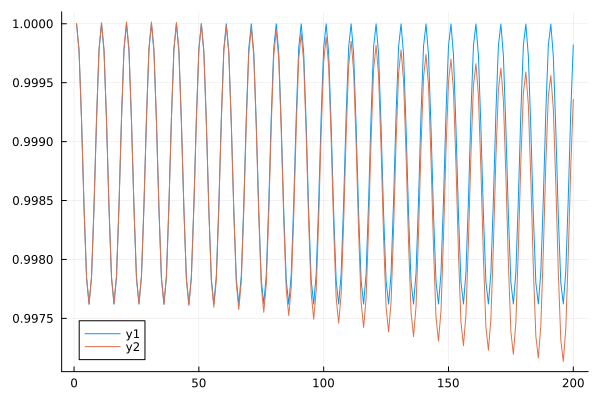

In [60]:
plot(rtraj_scaled)

#r is the norm of the position of the trajectory with control applied 
plot!(r) 

In [61]:
r[1]*position_scale 

6791.0

In [62]:
#r at the end of 10 revolutions when low thrust is applied (in km)
r[end]*position_scale 

6786.630423522501

In [63]:
#at the end, r decreases by 10 km. takes 8 min to compute a solution for 10 revs.

In [64]:
#transform into matrices for plotting 
q = zeros(3, N)
v = zeros(3, N)
a = zeros(3, N)
u = zeros(3, N-1)


for i=1:N

    q[:,i] = q_vector[i]
    v[:,i] = v_vector[i]
    a[:,i] = a_vector[i]

end

for i=1:N-1

    u[:,i] = u_vector[i]
    
end

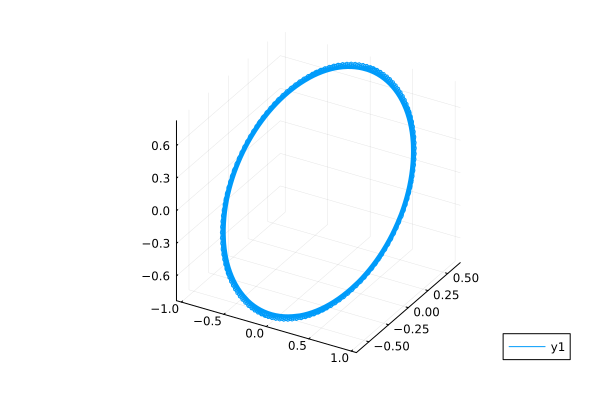

In [65]:
plot(q[1,:], q[2,:], q[3,:])

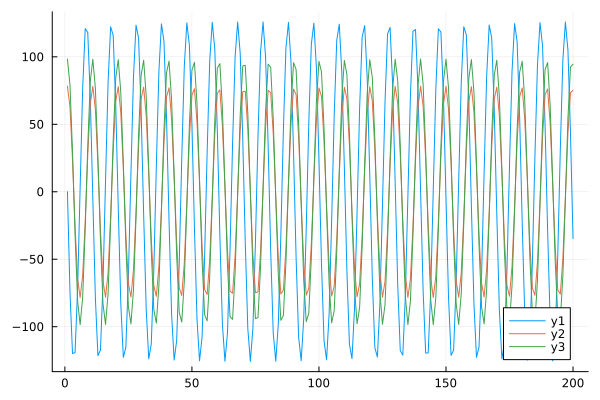

In [66]:
plot(v[1,:])
plot!(v[2,:])
plot!(v[3,:])

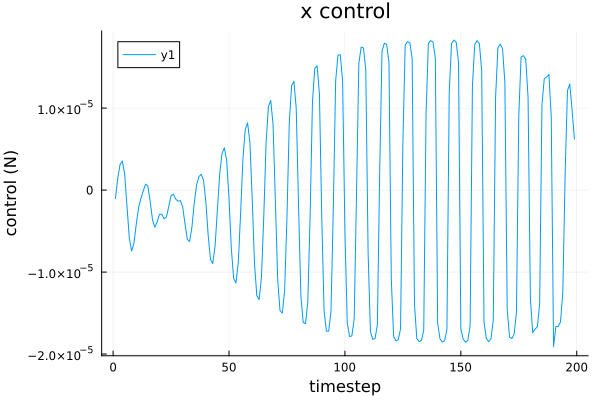

In [67]:
plot(u[1,:]*acceleration_scale*1e3, title="x control", xlabel="timestep", ylabel="control (N)")

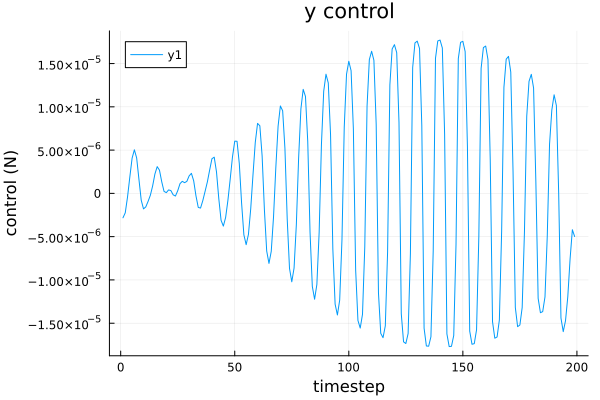

In [68]:
plot(u[2,:]*acceleration_scale*1e3, title="y control", xlabel="timestep", ylabel="control (N)")

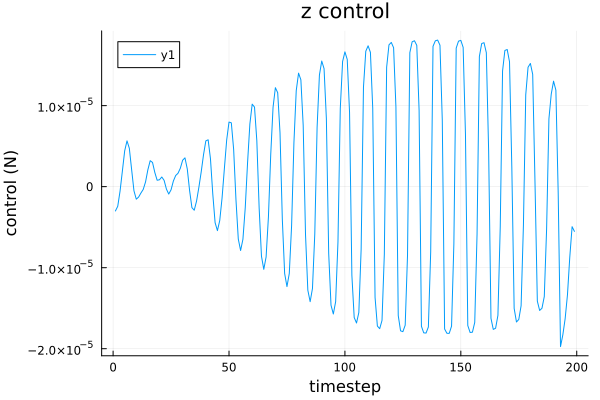

In [69]:
plot(u[3,:]*acceleration_scale*1e3, title="z control", xlabel="timestep", ylabel="control (N)") 

In [70]:
u 

3×199 Matrix{Float64}:
 -0.00188563   0.00261242   0.00568993   …   0.0177349    0.0113543
 -0.00515629  -0.00410078  -0.000745936     -0.00767153  -0.00910565
 -0.00548179  -0.00442999  -0.00100694      -0.00902368  -0.0100831

In [71]:
#check the constraints for the slack 

In [72]:
s_check = norm(r.^2 - s) 

1.2560739669470201e-15

In [73]:
w_check = norm(r.^3- w)  

1.8107189559191205e-15